# Assignment 1: Linear regression implementation

This notebook follows a linear-regression workflow: inspect and plot the data, compare NumPy and scikit-learn least-squares fits, implement gradient descent, examine convergence under different learning rates and iteration counts, and compare test RMS across model feature sets. The train/test split is deterministic (`random_state=42`). Test/train ratios are 0.25, 0.5, and 1.0.

**Metric:** RMS = square root of the mean squared prediction error on held-out rows. Coefficients are reported as `y = X @ w + b`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42


## Data and model definitions

Carsmall: predict horsepower from MPG and weight. Model (a) fits a straight line from MPG; model (b) adds MPG squared so the curve can bend; model (c) also uses weight. The data cell creates `MPG_sq` and removes rows missing any required value, so all three models are compared on the same 93 cars.


In [2]:
# Read the included CSV. All required data files are stored beside this notebook.
df = pd.read_csv("carsmall1.csv")
# Remove an exported row index column, if present.
df = df.loc[:, ~df.columns.astype(str).str.match(r"^Unnamed")]

# Add polynomial terms used by the requested models.
df["MPG_sq"] = df["MPG"] ** 2
target = "Horsepower"
feature_sets = {
    "a": ['MPG'],
    "b": ['MPG', 'MPG_sq'],
    "c": ['MPG', 'MPG_sq', 'Weight'],
}
required = sorted({target, *[feature for features in feature_sets.values() for feature in features]})
df = df.dropna(subset=required).reset_index(drop=True)
print(f"Rows used: {len(df)}")
display(df.head())
display(df[required].describe().round(2))


Rows used: 93


,Acceleration,Horsepower,MPG,Model,Weight,MPG_sq
0,12.0,130,18.0,c,3504,324.0
1,11.5,165,15.0,b,3693,225.0
2,11.0,150,18.0,p,3436,324.0
3,12.0,150,16.0,a,3433,256.0
4,10.5,140,17.0,f,3449,289.0


,Horsepower,MPG,MPG_sq,Weight
count,93.00,93.00,93.00,93.00
mean,109.34,23.73,627.48,2962.51
std,45.35,8.08,403.90,805.97
min,46.00,9.00,81.00,1795.00
25%,81.00,16.50,272.25,2245.00
50%,90.00,24.00,576.00,2774.00
75%,140.00,29.00,841.00,3609.00
max,225.00,44.00,1936.00,4732.00


## Visualize the data

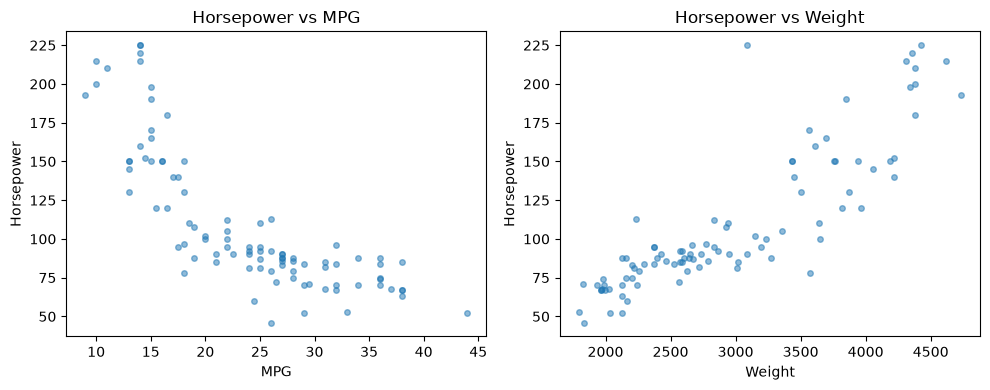

In [3]:
# Show how the target varies with each original predictor.
base_features = ['MPG', 'Weight']
fig, axes = plt.subplots(1, len(base_features), figsize=(5 * len(base_features), 4))
for ax, feature in zip(axes, base_features):
    ax.scatter(df[feature], df[target], alpha=0.5, s=16)
    ax.set_xlabel(feature)
    ax.set_ylabel(target)
    ax.set_title(f"{target} vs {feature}")
plt.tight_layout()
plt.show()


## Fit coefficients and compare implementations

The first fit uses all available rows to report each model's coefficients. Features are standardized inside the least-squares calculation to improve numerical stability, then coefficients are converted back to the original units. The next cell compares all three models with scikit-learn. Full-data fits describe the data; test RMS below comes only from models trained on training rows.


In [4]:
def fit_least_squares(X, y):
    """Fit stable least squares and return coefficients in the original units."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    # Center and scale predictors before solving to limit rounding errors.
    centers = X.mean(axis=0)
    scales = X.std(axis=0)
    scales = np.where(scales == 0, 1.0, scales)
    design = np.column_stack([(X - centers) / scales, np.ones(len(y))])
    theta, *_ = np.linalg.lstsq(design, y, rcond=None)
    # Convert coefficients back to the CSV column units for reporting.
    weights = theta[:-1] / scales
    bias = float(theta[-1] - centers @ weights)
    return weights, bias

full_fits = {}
for name, features in feature_sets.items():
    X = df[features].to_numpy(dtype=float)
    y = df[target].to_numpy(dtype=float)
    w, bias = fit_least_squares(X, y)
    full_fits[name] = (w, bias)
    print(f"Model {name}: features={features}")
    print(f"  w={w}; b={bias:.8f}")
    print(f"  equation: {target} = " + " + ".join(
        [f"({coef:.8g} * {feature})" for coef, feature in zip(w, features)] + [f"({bias:.8g})"]
    ))
    print()


Model a: features=['MPG']
  w=[-4.5068803]; b=216.27345564
  equation: Horsepower = (-4.5068803 * MPG) + (216.27346)

Model b: features=['MPG', 'MPG_sq']
  w=[-16.03425112   0.23404617]; b=342.91005463
  equation: Horsepower = (-16.034251 * MPG) + (0.23404617 * MPG_sq) + (342.91005)

Model c: features=['MPG', 'MPG_sq', 'Weight']
  w=[-10.25375057   0.15586245   0.02251544]; b=188.11970882
  equation: Horsepower = (-10.253751 * MPG) + (0.15586245 * MPG_sq) + (0.022515444 * Weight) + (188.11971)



## One-feature cost surface

The surface shows training mean squared error (MSE) for different values of the slope `w` and intercept `b` in model (a). Its low point corresponds to the best fit on the available rows. The held-out RMS later in the notebook measures a different thing: prediction error on rows excluded from fitting.


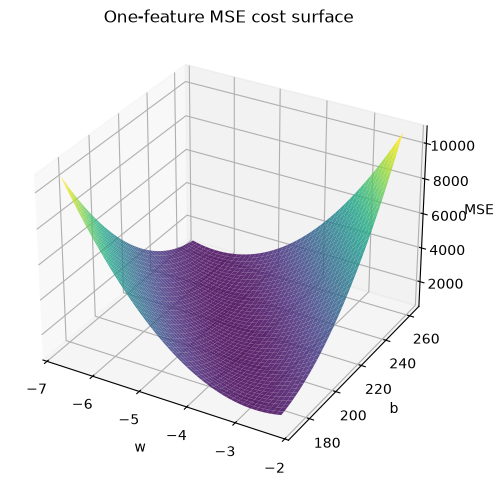

In [5]:
# Experiment: visualize the MSE surface for the first, one-feature model.
# The grid is centered on the least-squares solution so the minimum is visible.
x_cost = df[feature_sets["a"][0]].to_numpy(dtype=float)
y_cost = df[target].to_numpy(dtype=float)
w_star, b_star = fit_least_squares(x_cost.reshape(-1, 1), y_cost)
w_grid = np.linspace(w_star[0] - max(abs(w_star[0]) * 0.5, 1.0), w_star[0] + max(abs(w_star[0]) * 0.5, 1.0), 45)
b_grid = np.linspace(b_star - max(np.std(y_cost), 1.0), b_star + max(np.std(y_cost), 1.0), 45)
W, B = np.meshgrid(w_grid, b_grid)
Z = np.mean((W[..., None] * x_cost + B[..., None] - y_cost) ** 2, axis=2)
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(W, B, Z, cmap="viridis", alpha=0.85)
ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_zlabel("MSE")
ax.set_title("One-feature MSE cost surface")
plt.tight_layout()
plt.show()


In [6]:
# Compare two independent ordinary least-squares implementations for every model.
for name, features in feature_sets.items():
    X = df[features].to_numpy(dtype=float)
    y = df[target].to_numpy(dtype=float)
    w, bias = full_fits[name]
    reference = make_pipeline(StandardScaler(), LinearRegression()).fit(X, y)
    scaler = reference.named_steps["standardscaler"]
    regressor = reference.named_steps["linearregression"]
    reference_w = regressor.coef_ / scaler.scale_
    reference_b = regressor.intercept_ - scaler.mean_ @ reference_w
    predictions = X @ w + bias
    print(f"Model {name}: maximum weight difference = {np.max(np.abs(w - reference_w)):.3g}")
    print(f"  bias difference = {abs(bias - reference_b):.3g}")
    print(f"  training RMS = {np.sqrt(np.mean((y - predictions) ** 2)):.3f}")


Model a: maximum weight difference = 8.88e-16


  bias difference = 1.14e-13
  training RMS = 26.897
Model b: maximum weight difference = 1.6e-13
  bias difference = 1.82e-12
  training RMS = 21.523
Model c: maximum weight difference = 7.71e-13
  bias difference = 1.09e-11
  training RMS = 20.173


## Held-out RMS at different test/train ratios

For ratio `r`, the test fraction is `r / (1 + r)`: a ratio of 0.25 gives 80% training and 20% testing, while 1.0 gives a 50/50 split. All feature sets use the same seeded split for a given ratio. The pipeline learns feature scaling from training rows only, fits the regression, predicts held-out rows, and computes RMS. Lower test RMS means better predictions on that split.


In [7]:
rows = []
for ratio in (0.25, 0.5, 1.0):
    # Convert the requested test/train ratio to a fraction of all rows.
    test_fraction = ratio / (1.0 + ratio)
    for name, features in feature_sets.items():
        X = df[features].to_numpy(dtype=float)
        y = df[target].to_numpy(dtype=float)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_fraction, random_state=RANDOM_STATE
        )
        # StandardScaler is fitted only on X_train inside this pipeline.
        model = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train, y_train)
        predictions = model.predict(X_test)
        rows.append({
            "model": name,
            "features": ", ".join(features),
            "test/train ratio": ratio,
            "train rows": len(y_train),
            "test rows": len(y_test),
            "test RMS": np.sqrt(np.mean((y_test - predictions) ** 2)),
        })
rms_results = pd.DataFrame(rows)
display(rms_results.pivot(index="test/train ratio", columns="model", values="test RMS").round(3))
display(rms_results.round(3))


model,a,b,c
test/train ratio,,,
0.25,16.681,18.101,16.463
0.50,17.705,16.474,14.631
1.00,30.265,22.124,22.934


,model,features,test/train ratio,train rows,test rows,test RMS
0,a,MPG,0.25,74,19,16.681
1,b,"MPG, MPG_sq",0.25,74,19,18.101
2,c,"MPG, MPG_sq, Weight",0.25,74,19,16.463
3,a,MPG,0.50,62,31,17.705
4,b,"MPG, MPG_sq",0.50,62,31,16.474
5,c,"MPG, MPG_sq, Weight",0.50,62,31,14.631
6,a,MPG,1.00,46,47,30.265
7,b,"MPG, MPG_sq",1.00,46,47,22.124
8,c,"MPG, MPG_sq, Weight",1.00,46,47,22.934


## Polynomial degree experiment

This separate experiment fits degrees 1 through 5 using one predictor. The scaler is fitted on training rows before making polynomial features, which keeps large powers numerically manageable. Compare train and test RMS: a lower training error alone does not guarantee a lower test error. This experiment does not replace the three required feature-set comparisons.


,degree,train RMS,test RMS
0,1,24.971,30.265
1,2,21.516,22.124
2,3,20.344,22.789
3,4,20.301,21.620
4,5,19.897,26.583


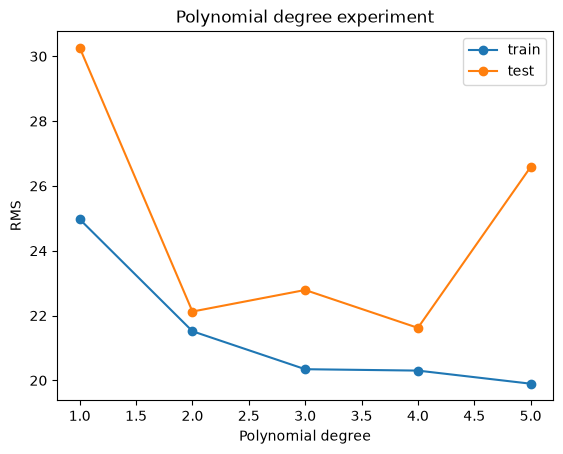

In [8]:
# Experiment: compare polynomial degree on one predictor.
# Reuse the largest test fraction (test/train = 1) for this degree sweep.
x_degree = df[["MPG"]].to_numpy(dtype=float)
y_degree = df[target].to_numpy(dtype=float)
X_train, X_test, y_train, y_test = train_test_split(
    x_degree, y_degree, test_size=0.5, random_state=RANDOM_STATE
)
degree_rows = []
for degree in range(1, 6):
    # Scale using training data before expanding powers to avoid huge values.
    model = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression(),
    ).fit(X_train, y_train)
    degree_rows.append({
        "degree": degree,
        "train RMS": np.sqrt(np.mean((y_train - model.predict(X_train)) ** 2)),
        "test RMS": np.sqrt(np.mean((y_test - model.predict(X_test)) ** 2)),
    })
degree_results = pd.DataFrame(degree_rows)
display(degree_results.round(3))
plt.plot(degree_results["degree"], degree_results["train RMS"], "o-", label="train")
plt.plot(degree_results["degree"], degree_results["test RMS"], "o-", label="test")
plt.xlabel("Polynomial degree")
plt.ylabel("RMS")
plt.title("Polynomial degree experiment")
plt.legend()
plt.show()


## Gradient descent and feature scaling

Gradient descent uses standardized input features and target values. We compare learning rates, iteration budgets, and zero versus nonzero initial weights. The update minimizes half the mean squared error; the displayed history reports mean squared error, which has the same minimum.

Each row reports the cost after the stated number of updates and its RMS after converting predictions back to the target's original units. These are full-data optimization diagnostics, not held-out test scores; use the preceding test RMS table to compare predictive performance.


In [9]:
def gradient_descent(X, y, learning_rate, iterations, initial_w=None, initial_b=0.0):
    """Batch gradient descent for half-MSE cost on standardized data."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)
    m, n = X.shape
    w = np.zeros(n) if initial_w is None else np.asarray(initial_w, dtype=float).copy()
    bias = float(initial_b)
    history = []
    for step in range(iterations):
        error = X @ w + bias - y
        dw = (X.T @ error) / m
        db = error.mean()
        w -= learning_rate * dw
        bias -= learning_rate * db
        if (step + 1) % max(1, iterations // 100) == 0 or step == iterations - 1:
            history.append(float(np.mean((X @ w + bias - y) ** 2)))
    return w, bias, history

# Demonstrate sensitivity to initialization, step size, and iteration budget.
features = feature_sets["c"]
X = df[features].to_numpy(dtype=float)
y = df[target].to_numpy(dtype=float)
x_scaler = StandardScaler().fit(X)
y_scaler = StandardScaler().fit(y.reshape(-1, 1))
X_scaled = x_scaler.transform(X)
y_scaled = y_scaler.transform(y.reshape(-1, 1)).ravel()
experiment_rows = []
for initialization, initial_w in (
    ("zero", np.zeros(X_scaled.shape[1])),
    ("0.1", np.full(X_scaled.shape[1], 0.1)),
):
    for rate in (0.01, 0.1, 0.5):
        for iterations in (100, 1000):
            w_gd, b_gd, history = gradient_descent(
                X_scaled, y_scaled, learning_rate=rate,
                iterations=iterations, initial_w=initial_w,
            )
            pred_scaled = X_scaled @ w_gd + b_gd
            pred = y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
            experiment_rows.append({
                "initial weights": initialization,
                "learning rate": rate,
                "iterations": iterations,
                "final scaled MSE": history[-1],
                "full-data RMS (original units)": np.sqrt(np.mean((y - pred) ** 2)),
            })
display(pd.DataFrame(experiment_rows).round(5))


,initial weights,learning rate,iterations,final scaled MSE,full-data RMS (original units)
0,zero,0.01,100,0.28485,24.07572
1,zero,0.01,1000,0.23390,21.81664
2,zero,0.10,100,0.23386,21.81501
3,zero,0.10,1000,0.20784,20.56525
4,zero,0.50,100,0.21746,21.03598
5,zero,0.50,1000,0.19999,20.17349
6,0.1,0.01,100,0.26473,23.20999
7,0.1,0.01,1000,0.23438,21.83908
8,0.1,0.10,100,0.23436,21.83821
9,0.1,0.10,1000,0.20803,20.57492


## Conclusion

The squared MPG term and Weight give the model more ways to represent the relationship than a single straight line. On the fixed seeded test splits, model (c) is best at test/train ratios 0.25 and 0.5; model (b) is best at ratio 1.0. This shows the added features can reduce error, though the advantage varies with the split. The dataset is small, and larger test fractions leave fewer training examples, so RMS error can vary across splits.

The fitted coefficients describe association in this dataset; they do not establish causal effects. Test RMS is measured on held-out rows and is the appropriate basis for comparing these models.

At a test/train ratio of 0.5, model (c) lowers RMS from 17.705 to 14.631 horsepower compared with model (a). At ratio 1.0, model (b) performs slightly better than model (c), so the extra weight feature is not uniformly helpful.

The coefficient table below describes a fit to all available rows; the RMS table comes from separate fits using only the training part of each split. A squared term means the effect of its base predictor can vary with its value, so its two coefficients should be interpreted together.

### Full-data fitted coefficients

| Model | Predictors | Weights w (in listed order) | Bias b |
|---|---|---|---|
| a | MPG | -4.50688 | 216.273 |
| b | MPG, MPG_sq | -16.0343, 0.234046 | 342.91 |
| c | MPG, MPG_sq, Weight | -10.2538, 0.155862, 0.0225154 | 188.12 |

### Held-out test RMS

| Model | Test/train ratio | Train n | Test n | RMS |
|---|---:|---:|---:|---:|
| a | 0.25 | 74 | 19 | 16.681 |
| a | 0.5 | 62 | 31 | 17.705 |
| a | 1 | 46 | 47 | 30.265 |
| b | 0.25 | 74 | 19 | 18.101 |
| b | 0.5 | 62 | 31 | 16.474 |
| b | 1 | 46 | 47 | 22.124 |
| c | 0.25 | 74 | 19 | 16.463 |
| c | 0.5 | 62 | 31 | 14.631 |
| c | 1 | 46 | 47 | 22.934 |